# 03 — When not to help: two monitors and the cost of saying no

> **Research question.** When the system cannot trust its evidence, what signals can warn it, and
> what is the cost of refusing assistance?

Third of three public notebooks (`01_signal_trust` → `02_confidence_under_shift` →
**`03_when_not_to_help`**), and the closest of the three to the Reborn question — *how should an
assistive robotic system decide when not to help?* For exactly that reason it has the strictest
scope discipline of the three.

**What this notebook is.** Offline, pilot-scale, illustrative evidence on two things: (1) which
*families of monitor* can notice that a classifier's evidence has stopped being trustworthy, and
(2) what abstaining — refusing to act on low-confidence predictions — buys and costs, measured
as a trade-off on recorded data.

**What this notebook is not.** It is not a hardware controller validation. There is no wearer, no
closed loop, no actuator, no device. No threshold in it is safe for hardware; none is
recommended. Classifier probability alone is not sufficient evidence for physical assistance
control, and nothing below suggests otherwise.

## Scope box

| | |
|---|---|
| Dataset | Ninapro DB6 (public; local download — `data/README.md`) |
| Subjects | `s01`, `s02` (two); monitor sections use `s02` only |
| Sessions | 10 per subject |
| Task | binary rest-vs-movement (Reborn's decision); LDA for the gate sweep, LDA + logistic regression for disagreement |
| Window set | the QC-gated cache shared with `01`/`02`; fingerprint printed below |
| Mode | **OFFLINE** |
| Scale | **PILOT / ILLUSTRATIVE** — cases, not coverage |

Artifacts: `experiments/results/nb03_*_<fingerprint>.csv`; figures from `figures/render.py`.

In [1]:
import csv
import json
import sys
from pathlib import Path

import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

from reborn.data.evaluation import (
    assist_availability,
    balanced_accuracy,
    coverage,
    expected_calibration_error,
    selective_risk,
    unsafe_assist_rate,
)
from reborn.data.features import batch_features, feature_matrix, standardize
from reborn.data.pipeline import load_window_set
from reborn.data.splits import cross_session_splits, within_session_splits
from reborn.decision.confidence_gate import ConfidenceGate
from reborn.ml.anomaly import AnomalyDetector
from reborn.sensing.features import anomaly_features

RESULTS = REPO / "experiments" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

CACHE = sorted((REPO / "data" / "cache").glob("db6_s01_s02_*.npz"))
assert CACHE, "run 01_signal_trust or 02_confidence_under_shift first to build the cache"
ws = load_window_set(CACHE[-1])
STAMP = ws.meta.get("config_fingerprint", "")
RATE = float(ws.meta.get("sample_rate", 1000.0))
subj = ws.subject_ids.astype(str)
sess = ws.session_ids.astype(str)
print(f"cache {CACHE[-1].name}: {ws.n_windows} QC-gated windows; fingerprint {STAMP}; sample rate {RATE:.0f} Hz")
print(f"subjects {sorted(set(subj))}, sessions per subject {len(set(sess))}")

cache db6_s01_s02_fed1e81a523e5d6e.npz: 259745 QC-gated windows; fingerprint fed1e81a523e5d6e; sample rate 1000 Hz


subjects [np.str_('s01'), np.str_('s02')], sessions per subject 10


## 1. Two families of monitor

A system that must decide *when not to help* needs to know when its evidence has stopped being
trustworthy. On this pipeline there are two places to look:

| family | what it models | examples here |
|---|---|---|
| **input monitors** | the signal — P(x) | deterministic QC (`reborn.sensing.emg_qc`); the advisory one-class anomaly detector (`reborn.ml.anomaly`) |
| **decision monitors** | the classifier's behaviour — P(y\|x) | the distribution of its confidence; disagreement between two models given the same input; the share of windows it calls "movement" |

Input monitors were the subject of `01_signal_trust`. This notebook asks whether they are enough,
by looking at the one cross-session case in `02_confidence_under_shift` where the binary
classifier's balanced accuracy collapsed, and then at the decision monitors.

## 2. An illustrative failure case the input monitors do not see

The setting, deliberately the same as `02`'s cross-session protocol: **one subject (`s02`), the
classifier and both anomaly detectors fit on the first session (`d01_t01`), everything else held
out.** The anomaly detectors are fit and calibrated on label-stratified halves of the training
session so that "clean" has the same gesture composition the detector was fit on (the control
`01` §5 established).

The collapse session is not chosen by hand: it is the held-out session with the **lowest binary
balanced accuracy**, computed below. The training session is printed for reference and is
**excluded from every comparison** — its recall is in-sample.

In [2]:
SUBJECT, TRAIN = "s02", "d01_t01"
CAP, CONTAMINATION = 3000, 0.025
s2 = subj == SUBJECT
s2_sessions = sorted(set(sess[s2]))


def idx_for(session):
    ix = np.flatnonzero(s2 & (sess == session))
    if len(ix) > CAP:
        ix = ix[np.linspace(0, len(ix) - 1, CAP).astype(int)]
    return ix


def ch_feats(ix, ch):
    return np.array([list(anomaly_features(w, RATE).values()) for w in ws.windows[ix, :, ch]])


def stratified_halves(labels):
    first, second = [], []
    for label in np.unique(labels):
        ii = np.flatnonzero(labels == label)
        first += ii[: len(ii) // 2].tolist(); second += ii[len(ii) // 2 :].tolist()
    return np.sort(first), np.sort(second)


train_ix = idx_for(TRAIN)
fit_half, cal_half = stratified_halves(ws.labels[train_ix])
detectors = {}
for ch in (0, 1):
    tr = ch_feats(train_ix, ch)
    detectors[ch] = AnomalyDetector(contamination=CONTAMINATION).fit(tr[fit_half], calibration=tr[cal_half])

Xtr, _ = batch_features(ws.windows[train_ix])
ytr = (ws.labels[train_ix] != 0).astype(int)  # binary: rest (0) vs movement (1)
(Xtr_s,) = standardize(Xtr)
lda = LinearDiscriminantAnalysis().fit(Xtr_s, ytr)
logreg = LogisticRegression(max_iter=2000).fit(Xtr_s, ytr)
train_move_share = float(np.mean(ytr == 1))

monitor_rows = []
for s in s2_sessions:
    ix = idx_for(s)
    Xte, _ = batch_features(ws.windows[ix])
    yte = (ws.labels[ix] != 0).astype(int)
    _, Xte_s = standardize(Xtr, Xte)
    proba = lda.predict_proba(Xte_s)
    pred = lda.classes_[np.argmax(proba, axis=1)]
    conf = np.max(proba, axis=1)
    monitor_rows.append(
        {
            "subject": SUBJECT,
            "session": s,
            "is_train": s == TRAIN,
            "n_windows": int(len(ix)),
            # input monitor
            "anom_flag_ch0": float(np.mean(detectors[0].distance(ch_feats(ix, 0)) > detectors[0].threshold)),
            "anom_flag_ch1": float(np.mean(detectors[1].distance(ch_feats(ix, 1)) > detectors[1].threshold)),
            # classifier outcome (needs labels — not a runtime monitor)
            "balanced_accuracy": balanced_accuracy(yte, pred),
            "rest_recall": float(np.mean(pred[yte == 0] == 0)) if np.any(yte == 0) else float("nan"),
            "move_recall": float(np.mean(pred[yte == 1] == 1)) if np.any(yte == 1) else float("nan"),
            "ece": expected_calibration_error(yte, pred, conf),
            # decision monitors (label-free)
            "mean_conf": float(np.mean(conf)),
            "disagreement": float(np.mean(pred != logreg.predict(Xte_s))),
            "move_pred_share": float(np.mean(pred == 1)),
        }
    )

test_rows = [r for r in monitor_rows if not r["is_train"]]
collapse = min(test_rows, key=lambda r: r["balanced_accuracy"])["session"]
for r in monitor_rows:
    r["is_highlighted"] = r["session"] == collapse

print(f"train session {SUBJECT}/{TRAIN}; lowest held-out balanced accuracy: {collapse}\n")
print(f"{'session':<10}{'anom ch0':>9}{'anom ch1':>9}{'bal.acc':>9}{'rest rec':>10}{'move rec':>10}{'ECE':>7}   note")
print("-" * 76)
for r in monitor_rows:
    note = "(train — in-sample, excluded)" if r["is_train"] else ("<- lowest balanced accuracy" if r["is_highlighted"] else "")
    print(f"{r['session']:<10}{r['anom_flag_ch0']:>9.1%}{r['anom_flag_ch1']:>9.1%}{r['balanced_accuracy']:>9.3f}"
          f"{r['rest_recall']:>10.3f}{r['move_recall']:>10.3f}{r['ece']:>7.3f}   {note}")

others = [r for r in test_rows if not r["is_highlighted"]]
hi = next(r for r in test_rows if r["is_highlighted"])
print(f"\nanomaly flag rate on {collapse}: ch0 {hi['anom_flag_ch0']:.1%} (other held-out sessions "
      f"{min(r['anom_flag_ch0'] for r in others):.1%}–{max(r['anom_flag_ch0'] for r in others):.1%}); "
      f"ch1 {hi['anom_flag_ch1']:.1%} (others {min(r['anom_flag_ch1'] for r in others):.1%}–{max(r['anom_flag_ch1'] for r in others):.1%})")

train session s02/d01_t01; lowest held-out balanced accuracy: d02_t02

session    anom ch0 anom ch1  bal.acc  rest rec  move rec    ECE   note
----------------------------------------------------------------------------
d01_t01        2.4%     3.0%    0.959     0.965     0.952  0.012   (train — in-sample, excluded)
d01_t02        3.1%     7.3%    0.933     0.950     0.917  0.026   
d02_t01        1.3%     6.4%    0.923     0.974     0.872  0.030   
d02_t02        1.2%    12.2%    0.639     0.696     0.582  0.190   <- lowest balanced accuracy
d03_t01        1.8%     4.1%    0.944     0.990     0.899  0.012   
d03_t02        1.2%     7.4%    0.933     0.993     0.872  0.028   
d04_t01        3.2%     5.9%    0.929     0.948     0.910  0.028   
d04_t02        1.6%     8.6%    0.952     0.997     0.907  0.014   
d05_t01        2.3%    13.6%    0.925     0.976     0.873  0.033   
d05_t02        1.8%     8.7%    0.942     0.994     0.891  0.024   

anomaly flag rate on d02_t02: ch0 1.2% (oth

### Reading

On the committed run the held-out session with the lowest balanced accuracy is the one both
recalls fall on — rest *and* movement — while the advisory anomaly detector does **not** single it
out: on channel 0 its flag rate is at the bottom of the held-out range (1.2%; only one other held-out session is marginally lower), and on channel 1 it sits
inside the range spanned by the other held-out sessions (the highest channel-1 rate belongs to a
session that classifies normally). The input looked ordinary to a model of P(x); the learned
rest/movement boundary did not apply to it. That is the pattern one would expect from a shift in
P(y|x) rather than P(x), and it is what an input monitor is blind to by construction.

This is **one session of one subject**. It is presented as an illustrative case, not as a rate.

## 3. Decision monitors — three label-free signals from the classifier's own behaviour

If the input looks normal but the boundary moved, the classifier's *behaviour* should betray it
without labels. Three runtime-computable signals per session, beside the input monitor:

- **mean confidence** — the distribution of the predicted-class probability, not the per-window
  value a gate consumes;
- **model disagreement** — the fraction of windows on which LDA and logistic regression, **both
  trained on the training session**, predict different classes **on the held-out session**;
- **predicted-movement share** — the fraction of windows called "movement", against the training
  session's.

In [3]:
print(f"{'session':<10}{'anom ch0':>9}{'mean conf':>11}{'disagree':>10}{'move-pred':>11}   note")
print("-" * 62)
for r in monitor_rows:
    note = "(train — in-sample, excluded)" if r["is_train"] else ("<- lowest balanced accuracy" if r["is_highlighted"] else "")
    print(f"{r['session']:<10}{r['anom_flag_ch0']:>9.1%}{r['mean_conf']:>11.3f}{r['disagreement']:>10.1%}{r['move_pred_share']:>11.1%}   {note}")
print(f"\ntraining-session predicted-movement share: {train_move_share:.1%}")
for key, label in (("mean_conf", "mean confidence"), ("disagreement", "disagreement"), ("move_pred_share", "predicted-movement share")):
    lo, hi_ = min(r[key] for r in others), max(r[key] for r in others)
    print(f"{label:<26} {collapse}: {hi[key]:.3f}   other held-out sessions: {lo:.3f}–{hi_:.3f}")

session    anom ch0  mean conf  disagree  move-pred   note
--------------------------------------------------------------
d01_t01        2.4%      0.943      3.1%      69.5%   (train — in-sample, excluded)
d01_t02        3.1%      0.951      4.1%      68.8%   
d02_t01        1.3%      0.924      5.4%      67.9%   
d02_t02        1.2%      0.787     22.5%      54.3%   <- lowest balanced accuracy
d03_t01        1.8%      0.927      5.1%      69.3%   
d03_t02        1.2%      0.927      5.5%      67.1%   
d04_t01        3.2%      0.948      5.0%      69.4%   
d04_t02        1.6%      0.942      5.2%      68.6%   
d05_t01        2.3%      0.929      6.8%      67.4%   
d05_t02        1.8%      0.941      6.1%      66.1%   

training-session predicted-movement share: 72.0%
mean confidence            d02_t02: 0.787   other held-out sessions: 0.924–0.951
disagreement               d02_t02: 0.225   other held-out sessions: 0.041–0.068
predicted-movement share   d02_t02: 0.543   other held-out s

### Reading

On the committed run the session that is unremarkable to the input monitor is loud on all three
decision signals: its mean confidence is the lowest of the held-out sessions, its LDA-vs-logreg
disagreement is several times any other session's, and its predicted-movement share falls well
below the others and the training session. Disagreement is the sharpest of the three and needs no
labels: two models fit on the same training data diverge on the held-out session on which
the boundary they learned no longer fits.

## 4. Complementarity — as existence evidence only

Put beside `01_signal_trust` §2, the two public notebooks now contain **two illustrative cases**:

| case | input monitor (QC / anomaly) | decision monitors | classifier |
|---|---|---|---|
| `s01/d04` (dropout episode) | deterministic QC rejected hundreds of dropout windows | — | no collapse of binary balanced accuracy (`02`) |
| `s02`, lowest-balanced-accuracy session from §2 (`d02_t02` in the committed run) | nothing unusual | confidence down, disagreement up, movement share down | balanced accuracy collapsed |

**What may be said:** DB6 contains cases in which one monitor family detects behaviour the other
does not. **What may not be said:** that a two-monitor architecture is validated, that the two
families provide established coverage of failure modes, or that either signal is a validated
detector. Two cases, one subject each, is existence evidence and nothing more.

## 5. The confidence rejector — an explicit gate, swept

`reborn.decision.confidence_gate.ConfidenceGate(low, high)` blocks assist below `low`, ramps to a
full ceiling at `high`, and is used here as a **hard gate** (`low = high = τ`): act if the
predicted-class probability is ≥ τ, abstain otherwise.

**The binary floor.** On a two-class task the predicted-class probability is never below 0.5, so
any τ ≤ 0.5 gates nothing. The τ = 0.50 row is kept in every table as the **ungated reference**
and is not a gating condition; the sweep proper runs from 0.55 to 0.99. No τ is recommended.

Predictions come from the binary LDA under `02`'s two protocols, refit per split with train-only
standardisation. Each quantity is computed **per split** and, separately, on the **pooled**
predictions of all splits of a protocol; the pooled curve is a summary of the per-split curves,
not a replacement for them.

In [4]:
Xb, _ = feature_matrix(ws)
yb = ws.binary_labels()
TAUS = [0.50] + [round(t, 2) for t in np.arange(0.55, 0.96, 0.05)] + [0.99]
GATES = {tau: ConfidenceGate(tau, tau) for tau in TAUS}

PROTOCOLS = {
    "within-session": within_session_splits(ws),
    "cross-session": cross_session_splits(ws, n_train_sessions=1),
}


def predict_split(sp):
    Xtr_s, Xte_s = standardize(Xb[sp.train_index], Xb[sp.test_index])
    model = LinearDiscriminantAnalysis().fit(Xtr_s, yb[sp.train_index])
    proba = model.predict_proba(Xte_s)
    return yb[sp.test_index], model.classes_[np.argmax(proba, axis=1)], np.max(proba, axis=1)


def sweep(y_true, y_pred, conf):
    rows = []
    for tau, gate in GATES.items():
        rows.append(
            {
                "tau": tau,
                "gated": tau > 0.5,
                "coverage": coverage(conf, gate),
                "selective_risk": selective_risk(y_true, y_pred, conf, gate),
                "unsafe_assist_rate": unsafe_assist_rate(y_true, y_pred, conf, gate),
                "assist_availability": assist_availability(y_true, y_pred, conf, gate),
                "n_windows": int(len(y_true)),
            }
        )
    return rows


per_split_rows, pooled_rows = [], []
for protocol, splits in PROTOCOLS.items():
    pooled = ([], [], [])
    for sp in splits:
        yt, yp, cf = predict_split(sp)
        for part, arr in zip(pooled, (yt, yp, cf)):
            part.append(arr)
        for row in sweep(yt, yp, cf):
            per_split_rows.append({"protocol": protocol, "split": sp.name, "subject": sp.meta.get("subject", ""), **row})
    for row in sweep(*(np.concatenate(p) for p in pooled)):
        pooled_rows.append({"protocol": protocol, "n_splits": len(splits), **row})
    print(f"{protocol}: {len(splits)} splits swept over {len(TAUS)} tau values")

within-session: 20 splits swept over 11 tau values


cross-session: 18 splits swept over 11 tau values


## 6. Risk–coverage

Definitions, as implemented in `reborn.data.evaluation`:

- **coverage(τ)** = fraction of **all** windows on which the gate lets the model act
  (`assist_scale > 0`). `1 − coverage` is the abstention rate.
- **selective risk(τ)** = error rate (`pred ≠ truth`) **among the covered windows only**.

Together these are the standard selective-prediction pair, and this table is the only one in the
notebook that may be called a risk–coverage curve.

In [5]:
def show(field_a, field_b, label_a, label_b):
    print(f"{'tau':>6}   {'within-session':^28}   {'cross-session':^28}")
    print(f"{'':>6}   {label_a:>13}{label_b:>15}   {label_a:>13}{label_b:>15}")
    print("-" * 70)
    for tau in TAUS:
        line = f"{tau:>6.2f}" + ("*" if tau <= 0.5 else " ")
        for protocol in PROTOCOLS:
            r = next(r for r in pooled_rows if r["protocol"] == protocol and r["tau"] == tau)
            line += f"  {r[field_a]:>13.3f}{r[field_b]:>15.4f}"
        print(line)
    print("* tau = 0.50: ungated reference (binary floor), not a gating condition")


print("pooled predictions per protocol\n")
show("coverage", "selective_risk", "coverage", "selective risk")

print("\nper-split spread of selective risk at each tau (min – median – max over splits)")
for protocol in PROTOCOLS:
    print(f"\n{protocol}")
    for tau in TAUS:
        vals = np.array([r["selective_risk"] for r in per_split_rows if r["protocol"] == protocol and r["tau"] == tau])
        cov = np.array([r["coverage"] for r in per_split_rows if r["protocol"] == protocol and r["tau"] == tau])
        vals = vals[np.isfinite(vals)]
        print(f"  tau {tau:.2f}   coverage {np.min(cov):.3f}–{np.max(cov):.3f}   "
              f"risk {np.min(vals):.4f} – {np.median(vals):.4f} – {np.max(vals):.4f}")

pooled predictions per protocol

   tau          within-session                 cross-session        
              coverage selective risk        coverage selective risk
----------------------------------------------------------------------
  0.50*          1.000         0.0570          1.000         0.0899
  0.55           0.986         0.0515          0.979         0.0817
  0.60           0.971         0.0459          0.956         0.0738
  0.65           0.955         0.0408          0.933         0.0662
  0.70           0.937         0.0360          0.907         0.0589
  0.75           0.919         0.0317          0.878         0.0516
  0.80           0.894         0.0273          0.845         0.0445
  0.85           0.863         0.0227          0.803         0.0369
  0.90           0.817         0.0181          0.744         0.0287
  0.95           0.733         0.0128          0.642         0.0196
  0.99           0.507         0.0061          0.402         0.0080
* tau = 0.

## 7. Unsafe assist vs. assist availability — a trade-off with two denominators

Two assist-specific quantities, gated by the same explicit τ:

- **unsafe-assist rate(τ)** = fraction of **all** windows where the gate would permit assist, the
  model says movement, and the truth is rest — assist the user did not ask for.
- **assist availability(τ)** = fraction of **true-movement windows** the gate would actually
  assist.

The denominators differ, so this pair is **not** a risk–coverage curve and is not called one; it
is the trade-off an assistance policy would face. Per-split values are shown beside the pooled
ones because a pooled average can hide a split where the same τ behaves very differently.

In [6]:
print("pooled predictions per protocol\n")
show("unsafe_assist_rate", "assist_availability", "unsafe", "availability")

print("\nper-split spread at two illustrative tau values (reference points for reading the figure, not recommendations)")
for tau_ref in (0.70, 0.90):
    print(f"\ntau = {tau_ref:.2f}")
    for protocol in PROTOCOLS:
        rows = [r for r in per_split_rows if r["protocol"] == protocol and r["tau"] == tau_ref]
        u = np.array([r["unsafe_assist_rate"] for r in rows]); a = np.array([r["assist_availability"] for r in rows])
        print(f"  {protocol:<16} unsafe {u.min():.4f} – {np.median(u):.4f} – {u.max():.4f}   "
              f"availability {a.min():.3f} – {np.median(a):.3f} – {a.max():.3f}   (n={len(rows)} splits)")
        worst = max(rows, key=lambda r: r["unsafe_assist_rate"])
        lowest = min(rows, key=lambda r: r["assist_availability"])
        print(f"  {'':<16} highest unsafe: {worst['split']} ({worst['unsafe_assist_rate']:.4f}); "
              f"lowest availability: {lowest['split']} ({lowest['assist_availability']:.3f})")

pooled predictions per protocol

   tau          within-session                 cross-session        
                unsafe   availability          unsafe   availability
----------------------------------------------------------------------
  0.50*          0.023         0.9543          0.023         0.9110
  0.55           0.020         0.9485          0.020         0.8993
  0.60           0.018         0.9416          0.018         0.8859
  0.65           0.015         0.9330          0.016         0.8711
  0.70           0.013         0.9224          0.014         0.8532
  0.75           0.012         0.9106          0.012         0.8321
  0.80           0.010         0.8944          0.010         0.8064
  0.85           0.008         0.8723          0.008         0.7717
  0.90           0.006         0.8369          0.006         0.7220
  0.95           0.004         0.7713          0.004         0.6344
  0.99           0.002         0.5794          0.001         0.4339
* tau = 0.

## 8. Abstention as a measurable trade-off

Read the two tables together and the shape is the same under both protocols: **raising τ lowers
selective risk and the unsafe-assist rate, and lowers coverage and availability, monotonically.**
Refusing more predictions removes some error, at the price of acting less. On the committed run,
cross-session coverage and availability at every gated τ are below within-session, and the
per-split spread is wider — the same τ that leaves one held-out session almost fully covered
leaves the collapsed session largely abstained-from.

That is what a confidence rejector *can* do on recorded data: convert a probability into a
coverage/error trade-off. What it cannot do is tell "this session's boundary moved, act less" from
"be conservative everywhere" — a per-window gate has no memory. That is the gap the decision
monitors of §3 point at, and it is left as the open question these notebooks hand on.

**This is not translated into clinical or device safety.** Lower unsafe-assist on a recorded
dataset is not a lower risk to a wearer; availability on labelled windows is not usability; and
none of the τ values is an operating point.

## 9. Artifacts

In [7]:
def write_csv(path, rows):
    if not rows:
        print(f"skipped {path.name}: nothing to write")
        return
    fields = list(dict.fromkeys(key for row in rows for key in row))
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)
    print(f"wrote {path.relative_to(REPO).as_posix()}  ({len(rows)} rows)")


write_csv(RESULTS / f"nb03_decision_monitors_{STAMP}.csv", monitor_rows)
rc_fields = ("protocol", "tau", "gated", "coverage", "selective_risk", "n_windows")
write_csv(RESULTS / f"nb03_risk_coverage_pooled_{STAMP}.csv", [{k: r[k] for k in ("n_splits",) + rc_fields if k in r} for r in pooled_rows])
write_csv(RESULTS / f"nb03_risk_coverage_per_split_{STAMP}.csv", [{k: r[k] for k in ("split", "subject") + rc_fields} for r in per_split_rows])
gs_fields = ("protocol", "tau", "gated", "unsafe_assist_rate", "assist_availability", "n_windows")
write_csv(RESULTS / f"nb03_gate_sweep_pooled_{STAMP}.csv", [{k: r[k] for k in ("n_splits",) + gs_fields if k in r} for r in pooled_rows])
write_csv(RESULTS / f"nb03_gate_sweep_per_split_{STAMP}.csv", [{k: r[k] for k in ("split", "subject") + gs_fields} for r in per_split_rows])

(RESULTS / f"nb03_run_{STAMP}.json").write_text(
    json.dumps(
        {
            "notebook": "03_when_not_to_help",
            "config_fingerprint": STAMP,
            "dataset": "ninapro_db6",
            "mode": "offline",
            "scale": "pilot, illustrative",
            "monitor_subject": SUBJECT,
            "monitor_train_session": TRAIN,
            "monitor_collapse_session": collapse,
            "monitor_windows_per_session": CAP,
            "anomaly_contamination": CONTAMINATION,
            "gate": "ConfidenceGate(tau, tau) — hard gate on predicted-class probability",
            "taus": TAUS,
            "ungated_reference_tau": 0.5,
            "gate_model": "binary LDA, train-only standardisation",
            "protocol_split_counts": {k: len(v) for k, v in PROTOCOLS.items()},
            "definitions": {
                "coverage": "fraction of all windows with assist_scale > 0",
                "selective_risk": "error rate among covered windows",
                "unsafe_assist_rate": "allowed & pred=movement & true=rest, over all windows",
                "assist_availability": "allowed & pred=movement, over true-movement windows",
            },
        },
        indent=2,
    )
)
print(f"wrote experiments/results/nb03_run_{STAMP}.json")

wrote experiments/results/nb03_decision_monitors_fed1e81a523e5d6e.csv  (10 rows)
wrote experiments/results/nb03_risk_coverage_pooled_fed1e81a523e5d6e.csv  (22 rows)
wrote experiments/results/nb03_risk_coverage_per_split_fed1e81a523e5d6e.csv  (418 rows)
wrote experiments/results/nb03_gate_sweep_pooled_fed1e81a523e5d6e.csv  (22 rows)
wrote experiments/results/nb03_gate_sweep_per_split_fed1e81a523e5d6e.csv  (418 rows)
wrote experiments/results/nb03_run_fed1e81a523e5d6e.json


## 10. Figures

Rendered from the CSVs in §9 by `figures/render.py`.

figures/F3_1_risk_coverage_fed1e81a523e5d6e.png


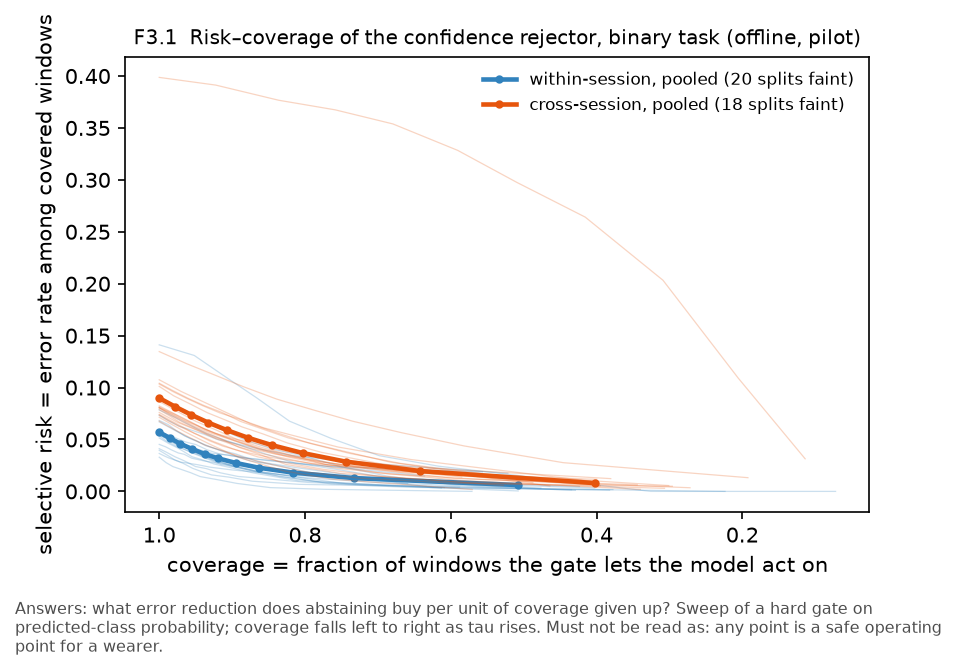

figures/F3_2_unsafe_vs_availability_fed1e81a523e5d6e.png


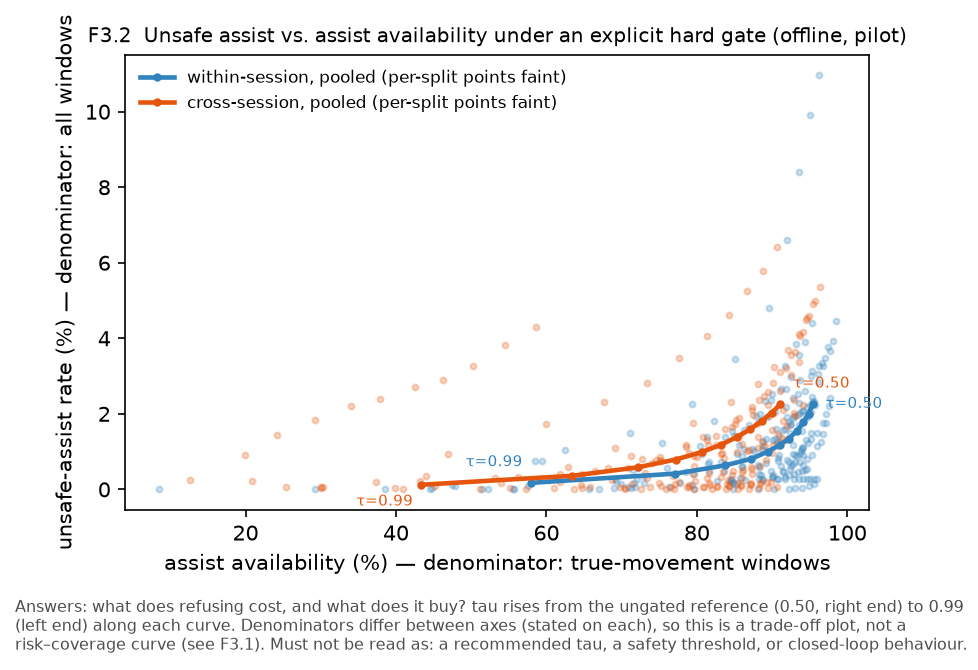

figures/F3_3_monitors_fed1e81a523e5d6e.png


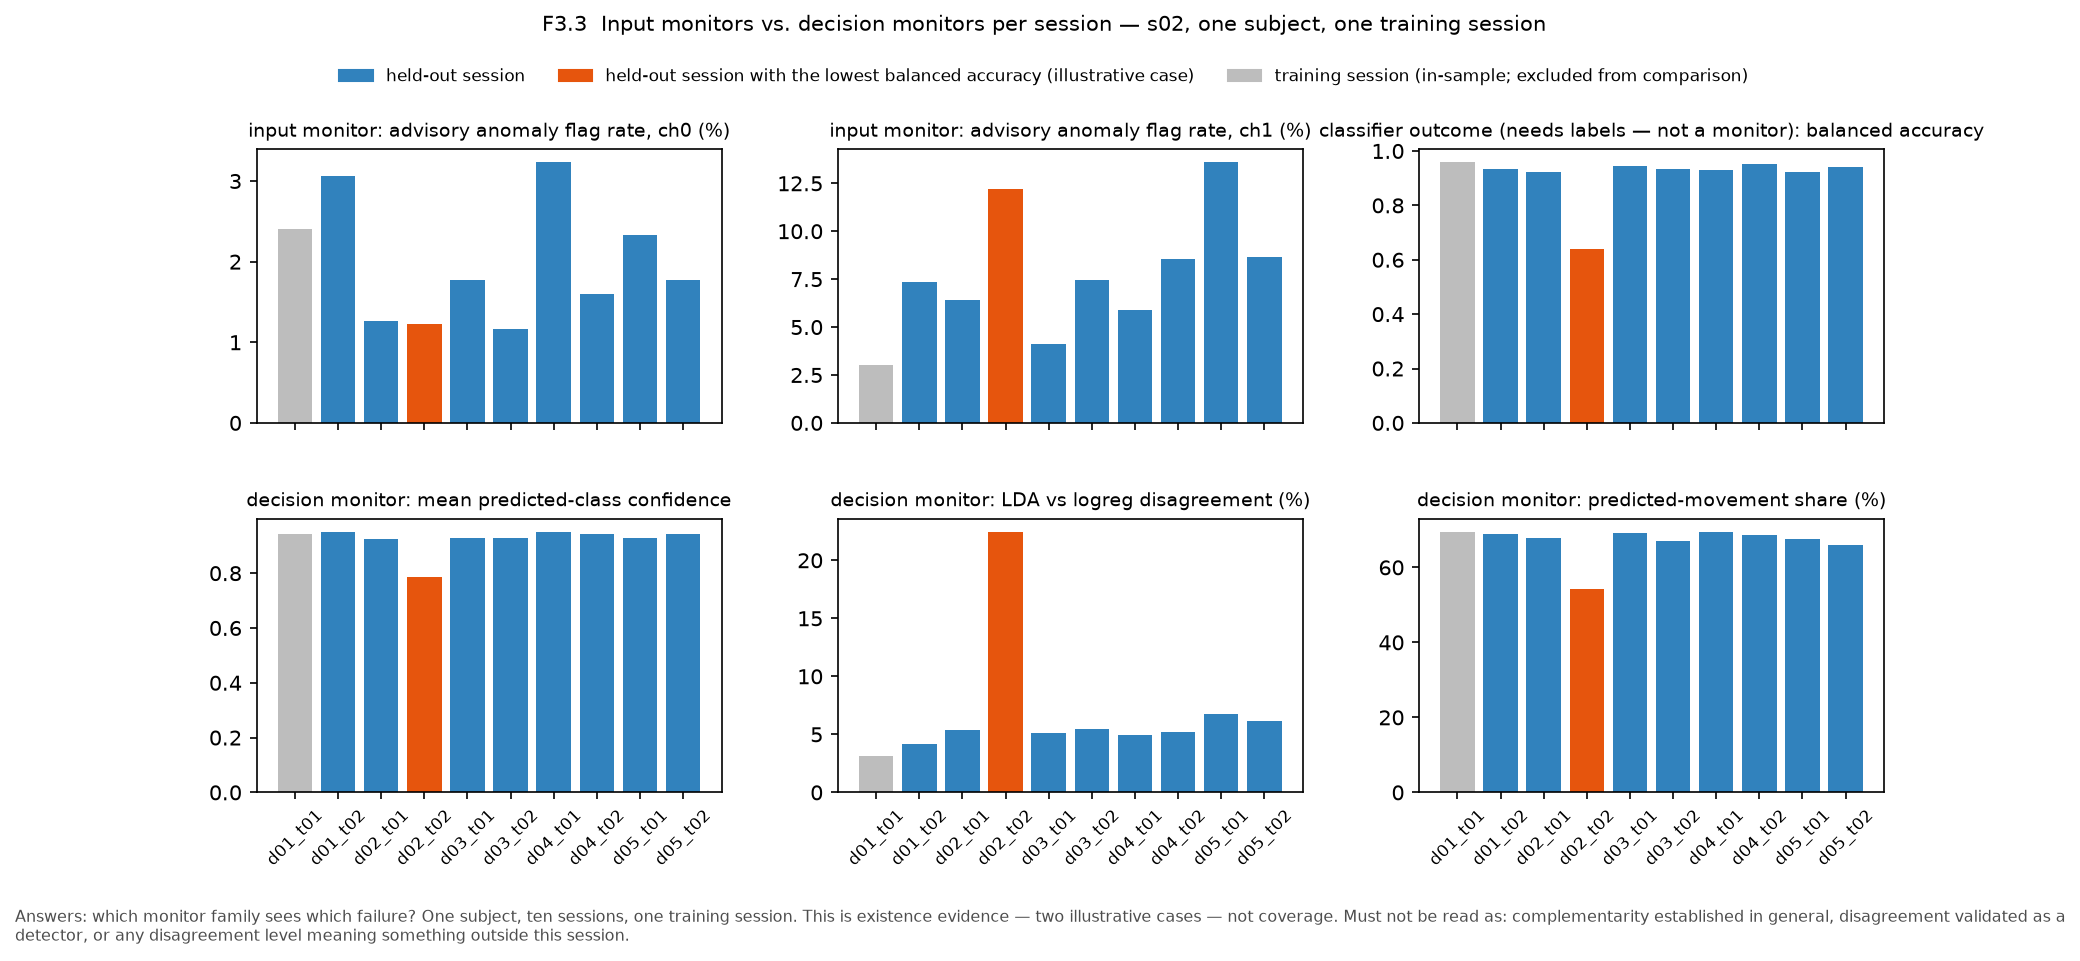

In [8]:
from IPython.display import Image, display

from figures.render import render_nb3

for path in render_nb3(RESULTS, REPO / "figures", STAMP):
    print(path.relative_to(REPO).as_posix())
    display(Image(filename=str(path)))

## 11. Limitations, and what this notebook must not be used to claim

**Limitations.** Offline. Pilot: two subjects in the window set, one subject in the monitor
sections. No wearer. No closed loop. No actuator. No device validation. One training session per
subject under the cross-session protocol, so per-split spread is test-session variability, not
independent replication. One collapse case; one contact-fault case (in `01`). Thresholds swept
here are properties of a classifier on a dataset and are **not hardware-safe**. Classifier
probability alone is not sufficient evidence for physical assistance control.

**Must not be read as:**

- that any τ is safe for real hardware, or is recommended;
- that abstention was validated with a wearer;
- that the two-monitor complementarity is established beyond the two illustrative cases;
- that disagreement, mean confidence or predicted-class share are validated detectors;
- that lower unsafe-assist on recorded windows is lower risk to a person.

**What it does contribute to the Reborn question.** The public evidence chain now reaches: signal
trust (`01`) → confidence reliability (`02`) → *offline* evidence about abstention (this
notebook): a rejector on the classifier's probability produces a monotone coverage/error
trade-off; the input monitors and the decision monitors each have an illustrative case the other
misses; and a per-window gate cannot by itself distinguish a shifted session from a merely
uncertain one. The next step in the chain — an assistance policy that uses these signals — is
future work and is not begun here.